# RandomForestRegressor

RandomForestRegressor predicts a continuous numerical value, such as:

- house price
- salary temperature
- sales
- travel time

It builds many DecisionTreeRegressor models using different random samples and feature subsets. Each tree predicts a value, and the forest returns their average. This usually provides more stable predictions and reduces overfitting compared with one decision tree.
$$prediction= \frac{Tree_1+Tree_2+Tree_3+.....+Tree_n}{n}$$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
data = {
    "age": [
        22, 25, 28, 30, 35, 40, 45, 32, 27, 50,
        24, 29, 33, 38, 42, 48, 26, 31, 36, 44
    ],

    "experience": [
        1, 2, 4, 5, 10, 15, 20, 7, 3, 25,
        1, 5, 8, 12, 17, 22, 2, 6, 11, 18
    ],

    # 1 = Bachelor, 2 = Master, 3 = PhD
    "education_level": [
        1, 1, 2, 2, 2, 3, 3, 2, 1, 3,
        1, 2, 2, 3, 3, 3, 1, 2, 2, 3
    ],

    "projects": [
        2, 3, 6, 8, 15, 20, 30, 10, 4, 35,
        2, 7, 12, 18, 25, 32, 3, 9, 16, 28
    ],

    "salary": [
        25000, 30000, 42000, 50000, 75000,
        100000, 135000, 62000, 35000, 160000,
        27000, 48000, 68000, 90000, 115000,
        145000, 32000, 57000, 80000, 125000
    ]
}

df = pd.DataFrame(data)

df.head()

,age,experience,education_level,projects,salary
0,22,1,1,2,25000
1,25,2,1,3,30000
2,28,4,2,6,42000
3,30,5,2,8,50000
4,35,10,2,15,75000


In [3]:
X = df.drop(columns=["salary"])
y = df["salary"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,age,experience,education_level,projects
0,22,1,1,2
1,25,2,1,3
2,28,4,2,6
3,30,5,2,8
4,35,10,2,15



Target:


0    25000
1    30000
2    42000
3    50000
4    75000
Name: salary, dtype: int64

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 15
Testing samples: 5


In [5]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

In [6]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [7]:
y_pred = model.predict(X_test)

result = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

result

,Actual Salary,Predicted Salary
0,25000,30080.000000
1,57000,51993.333333
2,145000,143200.000000
3,30000,31280.000000
4,35000,33300.000000


In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 2973.33
MSE  : 11728302.22
RMSE : 3424.66
R²   : 0.9941


In [9]:
new_person = pd.DataFrame({
    "age": [34],
    "experience": [9],
    "education_level": [2],
    "projects": [14]
})

predicted_salary = model.predict(new_person)

print(f"Predicted salary: {predicted_salary[0]:,.2f}")

Predicted salary: 70,670.00


In [10]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,experience,0.305072
0,age,0.291898
3,projects,0.264638
2,education_level,0.138391


In [11]:
print("Total importance:", model.feature_importances_.sum())

Total importance: 1.0


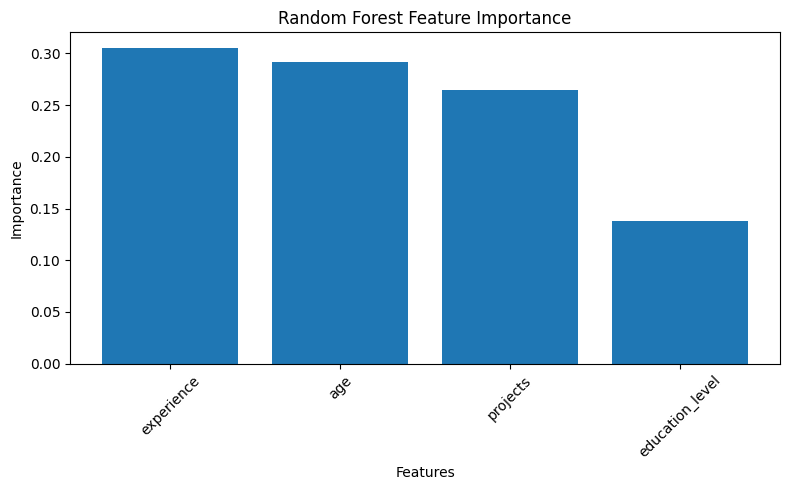

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
tree_predictions = []

for tree in model.estimators_[:10]:
    prediction = tree.predict(new_person)[0]
    tree_predictions.append(prediction)

print("First 10 tree predictions:")

for tree_number, prediction in enumerate(tree_predictions, start=1):
    print(f"Tree {tree_number}: {prediction:,.2f}")

print("\nAverage of first 10 trees:")
print(f"{np.mean(tree_predictions):,.2f}")

print("\nFinal prediction from all trees:")
print(f"{model.predict(new_person)[0]:,.2f}")

First 10 tree predictions:
Tree 1: 75,000.00
Tree 2: 68,000.00
Tree 3: 68,000.00
Tree 4: 68,000.00
Tree 5: 68,000.00
Tree 6: 75,000.00
Tree 7: 68,000.00
Tree 8: 68,000.00
Tree 9: 68,000.00
Tree 10: 68,000.00

Average of first 10 trees:
69,400.00

Final prediction from all trees:
70,670.00


/home/feroz/Desktop/python/first_ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/feroz/Desktop/python/first_ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/feroz/Desktop/python/first_ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/feroz/Desktop/python/first_ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/home/feroz/Desktop/python/first_ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, b